# Q Learning RTOS Visualizations: Printer Tasks
### Braden Everson

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

In [2]:
logs = pd.read_csv("../data/rtos/printer/printer1.csv")

baseline = pd.read_csv("../data/rtos/printer/baseline1.csv")

In [3]:
logs.tail()

,task_id,timestamp,total_run_timf,total_io_wait_time,total_ready_wait_time,wait_pct,delta
995,G,5124999,8818,9840552,12792,0.001297,33
996,G,5130844,8830,9851818,12806,0.001297,33
997,G,5136750,8840,9863076,12820,0.001297,33
998,G,5142631,8850,9874308,12834,0.001297,33
999,f,5143713,2608,10267714,6044,0.000588,17


In [4]:
baseline.tail()

,task_id,timestamp,total_run_timf,total_io_wait_time,total_ready_wait_time,wait_pct,delta
995,f,5124310,2634,10228930,6378,0.000623,10
996,G,5129940,8826,9850430,12802,0.001297,10
997,G,5135824,8836,9861706,12816,0.001297,10
998,G,5141750,8846,9872960,12830,0.001297,10
999,f,5144618,2660,10269400,6422,0.000625,10


Text(0.5, 0, 'Timestamp (us)')

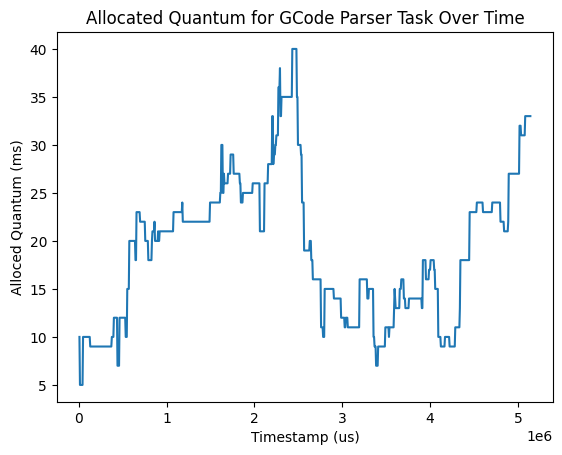

In [13]:
G = logs[logs["task_id"] == 'G']

plt.plot(G["timestamp"], G["delta"])
plt.title("Allocated Quantum for GCode Parser Task Over Time")
plt.ylabel("Alloced Quantum (ms)")
plt.xlabel("Timestamp (us)")

## Kruskal Wallis

In [6]:
run0 = pd.read_csv("../data/rtos/printer/printer1.csv")
run1 = pd.read_csv("../data/rtos/printer/printer2.csv")
run2 = pd.read_csv("../data/rtos/printer/printer3.csv")
run3 = pd.read_csv("../data/rtos/printer/printer4.csv")
run4 = pd.read_csv("../data/rtos/printer/printer5.csv")

baseline0 = pd.read_csv("../data/rtos/printer/baseline1.csv")
baseline1 = pd.read_csv("../data/rtos/printer/baseline2.csv")
baseline2 = pd.read_csv("../data/rtos/printer/baseline3.csv")
#baseline1 = pd.read_csv("../data/rtos/printer/baseline4.csv")
#baseline1 = pd.read_csv("../data/rtos/printer/baseline5.csv")

In [7]:
avgs = [
        run0["wait_pct"].mean()*100,
        run1["wait_pct"].mean()*100,
        run2["wait_pct"].mean()*100,
        run3["wait_pct"].mean()*100,
        run4["wait_pct"].mean()*100
       ]

baseline = [
    baseline0["wait_pct"].mean()*100,
    baseline1["wait_pct"].mean()*100,
    baseline2["wait_pct"].mean()*100,
#    baseline3["wait_pct"].mean()*100,
#    baseline4["wait_pct"].mean()*100,
]

In [8]:
baseline

[np.float64(0.5231961182585001),
 np.float64(0.5399763381352999),
 np.float64(0.5397346397826001)]

In [9]:
avgs

[np.float64(0.5225134223935),
 np.float64(0.5403076571459),
 np.float64(0.5415629834870002),
 np.float64(0.5430957391377),
 np.float64(0.5435243004524)]

In [10]:
np.array(avgs).mean()

np.float64(0.5382008205233)

Text(0, 0.5, 'Average System Wait Time (%)')

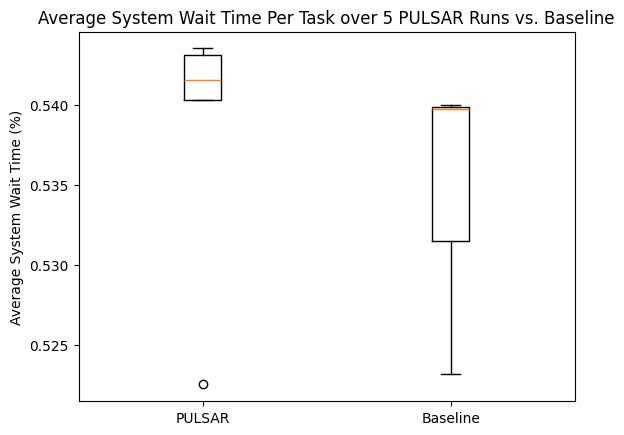

In [11]:
plt.boxplot([avgs, baseline], tick_labels=["PULSAR", "Baseline"])
plt.title("Average System Wait Time Per Task over 5 PULSAR Runs vs. Baseline")
plt.ylabel("Average System Wait Time (%)")

In [12]:
h_stat, p_val = stats.kruskal(avgs, baseline)

print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_val:.4f}")

H-statistic: 1.8000
P-value: 0.1797
